In [1]:
import numpy as np
import pandas as pd
# import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
df=pd.read_csv('House Price Prediction Dataset 1.csv')

In [3]:
df.isnull().sum()

Id           0
Area         0
Bedrooms     0
Bathrooms    0
Floors       0
YearBuilt    0
Location     0
Condition    0
Garage       0
Price        0
dtype: int64

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Id         2000 non-null   int64 
 1   Area       2000 non-null   int64 
 2   Bedrooms   2000 non-null   int64 
 3   Bathrooms  2000 non-null   int64 
 4   Floors     2000 non-null   int64 
 5   YearBuilt  2000 non-null   int64 
 6   Location   2000 non-null   object
 7   Condition  2000 non-null   object
 8   Garage     2000 non-null   object
 9   Price      2000 non-null   int64 
dtypes: int64(7), object(3)
memory usage: 156.4+ KB


In [5]:
df.head()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056


In [6]:
X = df.drop(columns=["Id", "Price"])
y = df["Price"]

In [7]:
categorical_features = ["Location", "Condition", "Garage"]
numerical_features = ["Area", "Bedrooms", "Bathrooms", "Floors", "YearBuilt"]

In [8]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first"), categorical_features),
        ("num", "passthrough", numerical_features)
    ]
)


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [10]:
model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])


In [11]:
model.fit(X_train, y_train)


,steps,"[('preprocessor', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [12]:
y_pred = model.predict(X_test)


In [13]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)


MAE : 243241.97758826384
MSE : 78321466146.03279
RMSE: 279859.72583784326
R2 Score: -0.006717808430749539


In [14]:
new_house = pd.DataFrame({
    "Area": [3000],
    "Bedrooms": [3],
    "Bathrooms": [2],
    "Floors": [2],
    "YearBuilt": [2010],
    "Location": ["Urban"],
    "Condition": ["Good"],
    "Garage": ["Yes"]
})

predicted_price = model.predict(new_house)
print("Predicted House Price:", predicted_price[0])


Predicted House Price: 518272.57000715885


In [24]:
import joblib
joblib.dump(model, "house_price_model.pkl")

['house_price_model.pkl']

In [15]:
import matplotlib.pyplot as plt

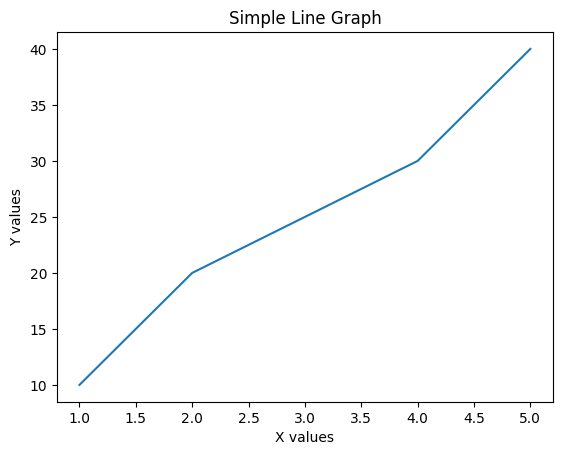

In [16]:
x = [1, 2, 3, 4, 5]
y = [10, 20, 25, 30, 40]

plt.plot(x, y)
plt.xlabel("X values")
plt.ylabel("Y values")
plt.title("Simple Line Graph")
plt.show()

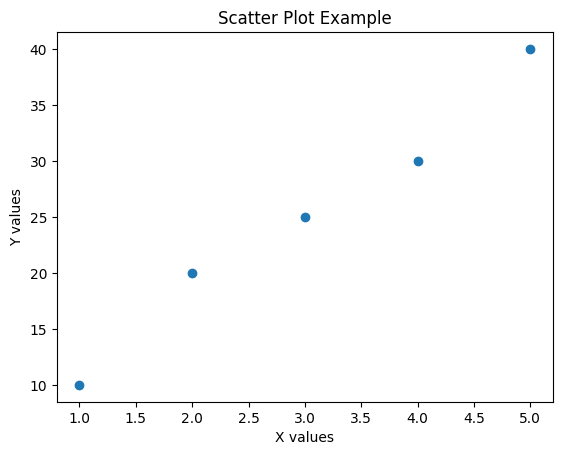

In [17]:
plt.scatter(x, y)
plt.xlabel("X values")
plt.ylabel("Y values")
plt.title("Scatter Plot Example")
plt.show()


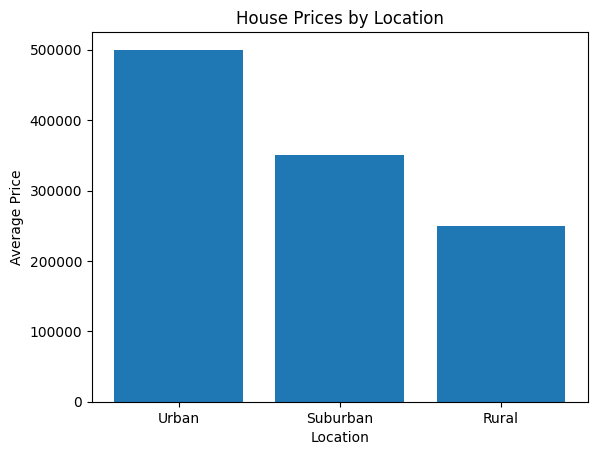

In [18]:
cities = ["Mumbai", "Pune", "Haydrabad"]
prices = [500000, 350000, 250000]

plt.bar(cities, prices)
plt.xlabel("Location")
plt.ylabel("Average Price")
plt.title("House Prices by Location")
plt.show()


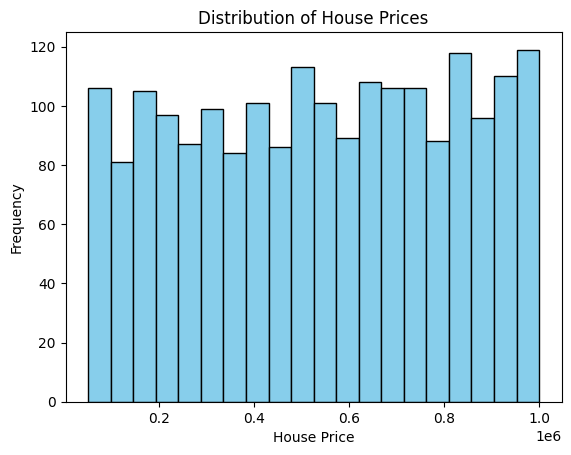

In [19]:
plt.hist(df["Price"], bins=20, color="skyblue", edgecolor="black")
plt.xlabel("House Price")
plt.ylabel("Frequency")
plt.title("Distribution of House Prices")
plt.show()


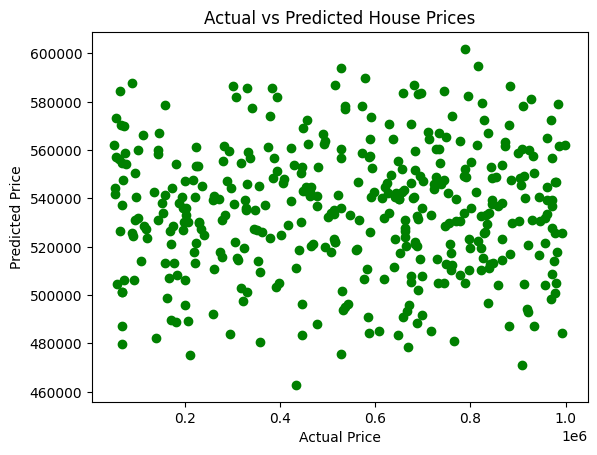

In [20]:
plt.scatter(y_test, y_pred, color="green")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")
plt.show()


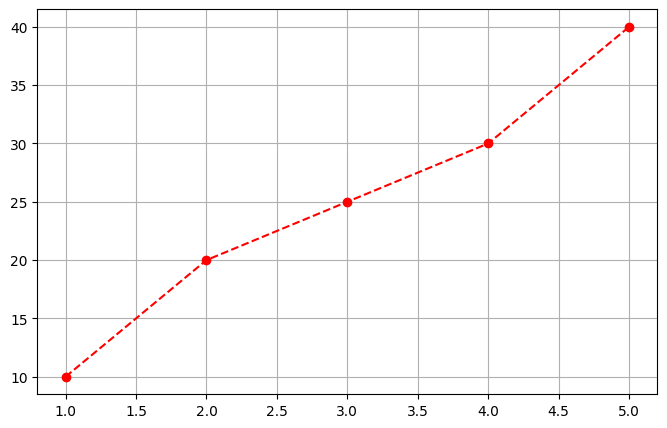

In [21]:
plt.figure(figsize=(8,5))
plt.plot(x, y, marker='o', linestyle='--', color='red')
plt.grid(True)
plt.show()


In [22]:
pip install streamlit

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [23]:
pip install joblib

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [25]:
import sklearn
print(sklearn.__version__)

1.7.2
